# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

<Double click this Markdown cell to make it editable, and record your answers here.>

1. I chose the census income dataset 
2. The label is income_binary, which indicates whether an individual's annual income is greater than 50,000 or less than or equal to 50,000. 
3. Age,occupation, years of experience, education level, etc
4. This matters because information here can help in decisions such as targeted marketing, identifying potential customers for financial products, allocating resources more effectively, improving business strategies, etc

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

In [3]:
# YOUR CODE HERE
print(df["income_binary"].value_counts())

<=50K    24720
>50K      7841
Name: income_binary, dtype: int64


### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [4]:
# YOUR CODE HERE
print(df.dtypes)

age               float64
workclass          object
fnlwgt              int64
education          object
education-num       int64
marital-status     object
occupation         object
relationship       object
race               object
sex_selfID         object
capital-gain        int64
capital-loss        int64
hours-per-week    float64
native-country     object
income_binary      object
dtype: object


In [5]:
print(df.isnull().sum())

age                162
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex_selfID           0
capital-gain         0
capital-loss         0
hours-per-week     325
native-country     583
income_binary        0
dtype: int64


In [6]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32399.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32236.000000
mean,38.589216,1.897784e+05,10.080679,615.907773,87.303830,40.450428
std,13.647862,1.055500e+05,2.572720,2420.191974,402.960219,12.353748
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,14084.000000,4356.000000,99.000000


<AxesSubplot:xlabel='age', ylabel='Count'>

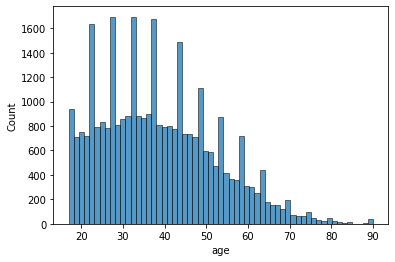

In [7]:
sns.histplot(data=df, x="age")

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

<Double click this Markdown cell to make it editable, and record your answers here.>

The EDA showed that the dataset has both numerical and categorical features, so categorical variables will need to be converted into numeric form. This can be done using one hot encoding. There are missing values in columns like age, workclass, occupation, hours-per-week, and native-country, which will need to be handled through imputation or by removing affected rows. The label is imbalanced with 24720 individuals earning <=50K and 7841 earning >50K. Because the majority class is very larger, I will use a stratified train test split to preserve the class distribution


### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

<Double click this Markdown cell to make it editable, and record your answers here.>

1. The Census Income dataset may contain biases because it was collected from the 1994 US Census and reflects the social and economic conditions of that time. Since stuff like employment and education were not equally available to everyone, historical patterns might be reflected in the data. Features like race, sex, marital status and native country can also serve as indirect indicators of protected characteristics. If these features are used without consideration, the model might unintentionally reinforce existing inequalities.

2. Incorrect predictions could have consequences. For example, if someone who actually earns less than 50k is predicted to earn more, they could miss out on opportunities they qualify for. Hence it is important to evaluate the model for fairness across different demographic groups and avoid relying on it as the only factor in high stakes decisions.


## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [8]:
df = df.dropna()
print(df.shape)
print(df.isnull().sum())

(29716, 15)
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex_selfID        0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income_binary     0
dtype: int64


In [9]:
# YOUR CODE HERE
df["income_binary"] = df["income_binary"].replace({"<=50K": 0, ">50K": 1})
numerical_cols = ["age", "hours-per-week"]
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].mean())

In [10]:
X = df.drop("income_binary", axis=1)
y = df["income_binary"]
X = pd.get_dummies(X, drop_first=True)
X.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39.0,77516,13,2174,0,40.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50.0,83311,13,0,0,13.0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,38.0,215646,9,0,0,40.0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,53.0,234721,7,0,0,40.0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,28.0,338409,13,0,0,40.0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

<Double click this Markdown cell to make it editable, and record your answers here.>

I prepared the data by first removing rows with missing values using the dropna() method. I chose to do this because the amount of missing data was relatively small and removing incomplete rows allowed me to create a clean dataset without needing to make assumptions about missing values. Then I converted the income_binary label into a numeric columns where <=50K was changed to 0 and >50K was changed to 1. This was necessary because machine learning models require numerical labels. I separated the features from the target variable and used one hot encoding to convert categorical features into numerical values. These features were kept because they may contain important information related to income prediction.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [11]:
# Create labeled examples from the dataset
# YOUR CODE HERE
X = X.copy()
y = y.copy()

In [12]:
# Create training and test sets out of the labeled examples 
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
# Train, test and evaluate your model
# YOUR CODE HERE
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="binary")
print("baseline accuracy:", accuracy)
print("baseline F1 score:", f1)
lr_accuracy = accuracy
lr_f1 = f1

baseline accuracy: 0.8426985195154778
baseline F1 score: 0.6517690875232773


In [14]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
# YOUR CODE HERE
param_grid = {"C": [0.01, 0.1, 1, 10], "solver": ["liblinear", "lbfgs"]}

grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring="f1")
grid_search.fit(X_train_scaled, y_train)
print("best parameters:")
print(grid_search.best_params_)

best parameters:
{'C': 0.01, 'solver': 'liblinear'}


In [15]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
# YOUR CODE HERE
best_model = grid_search.best_estimator_
best_model.fit(X_train_scaled, y_train)
final_predictions = best_model.predict(X_test_scaled)
final_accuracy = accuracy_score(y_test, final_predictions)
final_f1 = f1_score(y_test, final_predictions)
print("final accuracy:", final_accuracy)
print("final F1 score:", final_f1)

final accuracy: 0.843371467025572
final F1 score: 0.6548016314423434


In [16]:
# Interpret your model's outputs 
# YOUR CODE HERE
coefficients = pd.DataFrame({"Feature": X.columns,"Coefficient": best_model.coef_[0]})
coefficients["AbsCoefficient"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values(by="AbsCoefficient", ascending=False)
print(coefficients.head(10))

                              Feature  Coefficient  AbsCoefficient
3                        capital-gain     0.800378        0.800378
28  marital-status_Married-civ-spouse     0.584549        0.584549
2                       education-num     0.377452        0.377452
48             relationship_Own-child    -0.334343        0.334343
55              sex_selfID_Non-Female     0.332865        0.332865
5                      hours-per-week     0.318045        0.318045
0                                 age     0.302979        0.302979
35         occupation_Exec-managerial     0.275731        0.275731
50                  relationship_Wife     0.241079        0.241079
4                        capital-loss     0.236237        0.236237


### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

<Double click this Markdown cell to make it editable, and record your answers here.>

1. I chose logistic regression because this problem witht he census dataset is a binary classification problem where we have to predict whether an individual's income is greater than 50k usd. Logistic regression is well suited for binary classification and performs well on datasets with many variables after one hot encoding. It is also easy to interpret because the coefficients show how each feature influences the prediction.


2. I used GridSearchCV to test different values of the regularization parameter (C) and two different optimization solvers. The grid search identified the combination that produced the highest cross validated F1 score. This demonstrated that tuning hyperparameters can improve model performance and is better than hand picking these values. 

3. Logistic regression assigns a coefficient to each feature. Positive coefficients increases the chances that an individual earns more than 50k usd. Features with larger absolute coefficient values have a stronger influence on the prediction. 

4. Yes. The dataset includes sensitive features such as marital status and native country which could reflect biases present in the 1994 Census data. If the model is used in high stakes decisions, it could unintentionally reproduce inequality and target certain groups with their wrong predictions. 

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [17]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

print(X_train)
print(X_train_scaled)

        age  fnlwgt  education-num  capital-gain  capital-loss  \
23487  43.0   62857             10             0             0   
14141  52.0  193116              6             0             0   
16981  71.0  217971              5             0             0   
23455  70.0  304570             13             0             0   
25195  51.0  215404             13         14084             0   
...     ...     ...            ...           ...           ...   
18089  20.0  219122             10             0             0   
20919  20.0  194848             10             0             0   
27597  24.0  162919             10             0             0   
16791  26.0  152457              9             0             0   
1614   26.0  161007             13             0             0   

       hours-per-week  workclass_Local-gov  workclass_Private  \
23487            60.0                    0                  1   
14141            45.0                    0                  1   
16981       

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [18]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
# YOUR CODE HERE
nn_model.add(keras.layers.Input(shape=(n_features,)))

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.
# YOUR CODE HERE
#Using two layers for now with 64 and 32 units and will experiment later with different number of layers and units.Using at least two layers for now 
#will help model learn complex patterns in the data 
nn_model.add(keras.layers.Dense(64, activation="relu"))
nn_model.add(keras.layers.Dense(32, activation="relu"))

# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
# YOUR CODE HERE
#sigmoid because it converts to probability between 0 and 1 and then we can use those to look at the higher value
nn_model.add(keras.layers.Dense(1, activation="sigmoid"))

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                6208      
_________________________________________________________________
dense_1 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 33        
Total params: 8,321
Trainable params: 8,321
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [19]:
# Decision: What learning rate will you use? Add a comment explaining your decision.
# chose 0.01 because it is a common starting point and doesn't jump too far away or too slowly 

sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [20]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [21]:
# YOUR CODE HERE
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=["accuracy"])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [22]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [23]:
# Decision: How many epochs? Add a comment.

t0 = time.time() # start time

num_epochs = 100 

history = nn_model.fit(X_train_scaled, y_train, epochs=num_epochs, validation_split=0.2, callbacks=[ProgBarLoggerNEpochs(num_epochs)])


t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch 1/100
595/595 [==============================] - 5s 6ms/step - loss: 0.4611 - accuracy: 0.7984 - val_loss: 0.3837 - val_accuracy: 0.8290
Epoch 2/100
595/595 [==============================] - 3s 5ms/step - loss: 0.3523 - accuracy: 0.8433 - val_loss: 0.3437 - val_accuracy: 0.8419
Epoch 3/100
595/595 [==============================] - 3s 5ms/step - loss: 0.3333 - accuracy: 0.8488 - val_loss: 0.3371 - val_accuracy: 0.8442
Epoch 4/100
595/595 [==============================] - 3s 5ms/step - loss: 0.3262 - accuracy: 0.8508 - val_loss: 0.3310 - val_accuracy: 0.8463
Epoch 5/100
595/595 [==============================] - 3s 5ms/step - loss: 0.3223 - accuracy: 0.8527 - val_loss: 0.3273 - val_accuracy: 0.8486
Epoch 6/100
595/595 [==============================] - 3s 5ms/step - loss: 0.3196 - accuracy: 0.8516 - val_loss: 0.3271 - val_accuracy: 0.8477
Epoch 7/100
595/595 [==============================] - 4s 6ms/step - loss: 0.3172 - accuracy: 0.8530 - val_loss: 0.3252 - val_accuracy: 0.8482

595/595 [==============================] - 2s 3ms/step - loss: 0.2739 - accuracy: 0.8725 - val_loss: 0.3276 - val_accuracy: 0.8538
Epoch 58/100
595/595 [==============================] - 2s 4ms/step - loss: 0.2729 - accuracy: 0.8741 - val_loss: 0.3296 - val_accuracy: 0.8528
Epoch 59/100
595/595 [==============================] - 2s 3ms/step - loss: 0.2724 - accuracy: 0.8732 - val_loss: 0.3311 - val_accuracy: 0.8509
Epoch 60/100
595/595 [==============================] - 2s 4ms/step - loss: 0.2722 - accuracy: 0.8741 - val_loss: 0.3284 - val_accuracy: 0.8526
Epoch 61/100
595/595 [==============================] - 4s 6ms/step - loss: 0.2716 - accuracy: 0.8736 - val_loss: 0.3293 - val_accuracy: 0.8505
Epoch 62/100
595/595 [==============================] - 2s 4ms/step - loss: 0.2707 - accuracy: 0.8747 - val_loss: 0.3310 - val_accuracy: 0.8513
Epoch 63/100
595/595 [==============================] - 2s 3ms/step - loss: 0.2706 - accuracy: 0.8752 - val_loss: 0.3291 - val_accuracy: 0.8511
Epoch

### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



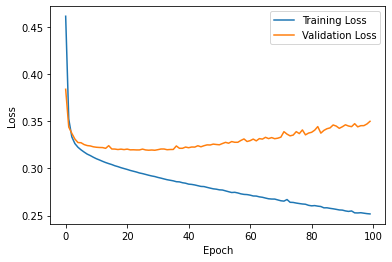

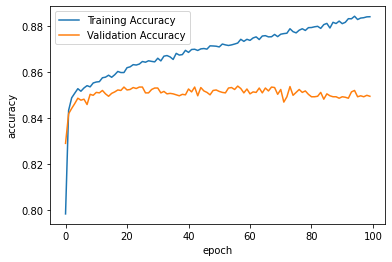

In [24]:
# Plot training loss and validation loss over epochs
# YOUR CODE HERE
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot training accuracy and validation accuracy over epochs
# YOUR CODE HERE
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [25]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

# YOUR CODE HERE
y_pred_probs = nn_model.predict(X_test_scaled)
y_pred = (y_pred_probs >= 0.5).astype(int)


In [26]:
# Compute accuracy and F1 score for the neural network and print the results

# YOUR CODE HERE
nn_accuracy = accuracy_score(y_test, y_pred)
nn_f1 = f1_score(y_test, y_pred)

print("neural network accuracy", nn_accuracy)
print("neural network F1 score", nn_f1)

neural network accuracy 0.8384925975773889
neural network F1 score 0.6689655172413792


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

<Double click this Markdown cell to make it editable, and record your answers here.>
1. Number of layers = 2, number of unites for first layer = 64 and second layer = 32, learning rate = 0.01 and number of epochs = 100. I made these choices as these are some default numbers that we could tezt our model with. In the end, we can always optimize and find the right numbers. 
2. The training curves tell me that this model is being overfitted. This is because over the epochs, the training loss decreses and validation loss increases and vice versa for the accuracy. This fits to the definition of overfitting. 
3. The F1 score here is 0.6149545772187281 which is not a desired result. The accuracy on test set is 0.8146029609690444 which is worse than accuracy on training set towards the end (which is 0.9173). This means that the model does not generalize well. I am nog surprised because the training curved showed that this model is overfitted.  

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [27]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
# results = pd.DataFrame({
#     'Metric': ['Accuracy', 'F1 Score'],
#     'KNN Model': [knn_accuracy, knn_f1],
#     'Neural Network': [nn_accuracy, nn_f1]
# })
# print(results.to_string(index=False))
#
# YOUR CODE HERE

results = pd.DataFrame({
     'Metric': ['Accuracy', 'F1 Score'],
     'Logistic Regression Model': [accuracy, f1],
     'Neural Network': [nn_accuracy, nn_f1]
})
print(results.to_string(index=False))

   Metric  Logistic Regression Model  Neural Network
 Accuracy                   0.842699        0.838493
 F1 Score                   0.651769        0.668966


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

<Double click this Markdown cell to make it editable, and record your answers here.>
1. Logistic regression model outperformed neural network model in accuracy here and vice verse in F1 score. 
2. The added complexity was not worth it as it just made the result worse. The performance difference for both the metrics was about 2% different. Neural network also took longer to run. LR was easier to run and gave better performance. 
3. I would recommend deploying logistic regression as it gave better performance, is simpler and faster to run and is easy to tune and figure out what is happening (i.e it is not black box). LR also helps interpret the model's output better by giving feature coefficients which tells us which features is LR giving more importance to in decision making and makes it easy to debug.
4. I would try different architechtures for the neural network. I would try a smaller network and use smaller number of units than 64 and 32. I would also try differen type of regularization on LR such as L2 regularization.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

<Double click this Markdown cell to make it editable, and record your answers here.>

1. I used google search a lot of times to google syntax for ways to do certain tasks. I looked at AI summary in search engine for the syntax. 
2. The most challenging part was picking the number of units and epochs to start with to train the neural network. I ended up choosing the numbers based on common size of neural network architectures I have seen so far. I did not use AI for this. 
3. I verified if my work was correct by checking for any errors generally and printing frquently and checking if it was expected output or not.
4. I would try to remember syntaxes more next time. 